<a href="https://colab.research.google.com/github/ruchithagoud-hash/viswam-ai-chat-assistant-/blob/main/Restaurant_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Restaurant Review Sentiment Analysis and Comparison


In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

nltk.download('stopwords', quiet=True)

True

In [2]:
df = pd.read_csv("Restaurant_Reviews.tsv", delimiter='\t', encoding='latin-1')

df.columns = ['review', 'sentiment']

df.head()

ParserError: Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.


In [3]:
df = pd.read_csv(
    "Restaurant_Reviews.tsv",
    delimiter='\t',
    encoding='latin-1',
    engine='python',
    on_bad_lines='skip'
)

df.columns = ['review', 'sentiment']

df.head()

,review,sentiment
0,»(?ê6ÕXï£ü,None
1,|±Ú5#£ì÷±¿ðWnúÚß§³ »S½LV;þä.ö²\©Ç(Ó>...,None
2,"Z=¤¬Â°«åÍiÛÉ_±ç;y°,±ìXMàß¯ù±«ÀÕÆZf)[)»'...",None
3,¿&rÈSÀ ðM¶ëåÔ÷òÂn¨^6a÷$ ä¿öá7ÙDÈËC#û¹...,None
4,Ãé >*üËJy¨þ(OXÊJám²ùczS'ü Dáýôy|Õ­|wà<ð...,None


In [4]:
import pandas as pd

data = {
    "review": [
        "Wow loved this place",
        "Worst service ever",
        "Food was amazing",
        "Not tasty and bad experience",
        "Great food and friendly staff",
        "Very bad service and rude staff",
        "Delicious food and nice ambience",
        "Worst food I have ever had",
        "Good quality and fast service",
        "Terrible experience never coming again"
    ],
    "sentiment": [1,0,1,0,1,0,1,0,1,0]
}

df = pd.DataFrame(data)

df.head()

,review,sentiment
0,Wow loved this place,1
1,Worst service ever,0
2,Food was amazing,1
3,Not tasty and bad experience,0
4,Great food and friendly staff,1


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,sentiment,clean_review
0,Wow loved this place,1,wow loved place
1,Worst service ever,0,worst service ever
2,Food was amazing,1,food amazing
3,Not tasty and bad experience,0,tasty bad experience
4,Great food and friendly staff,1,great food friendly staff


In [6]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5


In [10]:
df_new = pd.read_csv("restaurant_review.csv")

df_new.head()

,restaurant,review
0,Mehfil,Best place to visit food very tasty service ve...
1,Mehfil,Ordered chilli chicken dry but got wet biryani...
2,Mehfil,Manager and staff are really good and friendly
3,Mehfil,Chicken biryani is flavorful and well cooked
4,Mehfil,Food is good but staff behavior is bad


In [11]:
df_new['clean_review'] = df_new['review'].apply(clean_text)

X_new = vectorizer.transform(df_new['clean_review'])

df_new['prediction'] = model.predict(X_new)

df_new.head()

,restaurant,review,clean_review,prediction
0,Mehfil,Best place to visit food very tasty service ve...,best place visit food tasty service kind,1
1,Mehfil,Ordered chilli chicken dry but got wet biryani...,ordered chilli chicken dry got wet biryani worst,0
2,Mehfil,Manager and staff are really good and friendly,manager staff really good friendly,1
3,Mehfil,Chicken biryani is flavorful and well cooked,chicken biryani flavorful well cooked,0
4,Mehfil,Food is good but staff behavior is bad,food good staff behavior bad,0


In [12]:
result = df_new.groupby('restaurant')['prediction'].mean()

print(result)

restaurant
Bawarchi    0.4
Mehfil      0.3
Paradise    0.4
Name: prediction, dtype: float64


In [13]:
best = result.idxmax()

print("Best Restaurant:", best)

Best Restaurant: Bawarchi


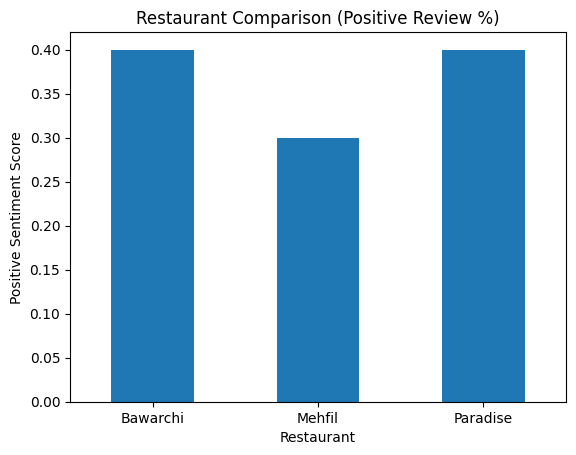

In [14]:
import matplotlib.pyplot as plt

result.plot(kind='bar')

plt.title("Restaurant Comparison (Positive Review %)")
plt.xlabel("Restaurant")
plt.ylabel("Positive Sentiment Score")
plt.xticks(rotation=0)
plt.show()

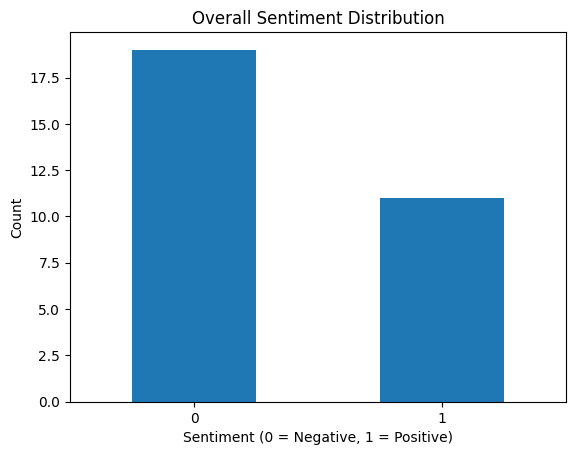

In [15]:
df_new['prediction'].value_counts().plot(kind='bar')

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

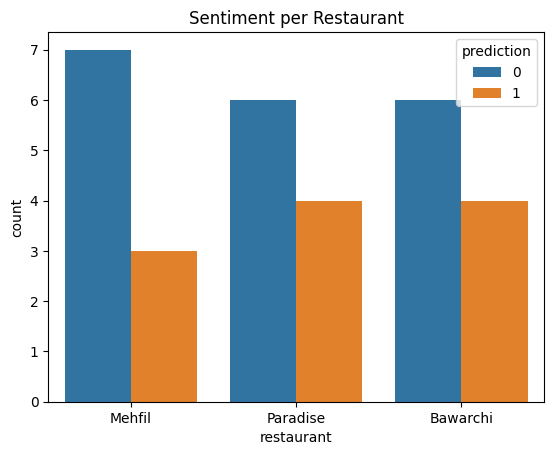

In [16]:
import seaborn as sns

sns.countplot(data=df_new, x='restaurant', hue='prediction')

plt.title("Sentiment per Restaurant")
plt.show()